In [50]:
import pandas as pd
import kagglehub
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [51]:
path = kagglehub.dataset_download("dmitriigluzdov/casmi26-natural-product-panel-benchmark")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Lenovo\.cache\kagglehub\datasets\dmitriigluzdov\casmi26-natural-product-panel-benchmark\versions\3


In [52]:

candidates_path = "C:/Users/Lenovo/.cache/kagglehub/datasets/dmitriigluzdov/casmi26-natural-product-panel-benchmark/versions/3/main_candidates.parquet"

df = pd.read_parquet(candidates_path)
print("Data Shape:", df.shape)
df.head()

Data Shape: (89418, 11)


,scenario,molecule,rank,candidate_key,ranker_score,formula,pool_row,popularity,pool_source,is_truth,lib_max
0,reference_in_other_libraries,AAWZDTNXLSGCEK,1,AAWZDTNXLSGCEK,0.780161,C7H12O6,21553,14.449219,3,True,0.880166
1,reference_in_other_libraries,AAWZDTNXLSGCEK,2,VFZFUKWNZRDVTB,-1.576765,C7H12O6,21555,3.134766,2,False,0.880166
2,reference_in_other_libraries,AAWZDTNXLSGCEK,3,YYPABUKAWQJAHV,-3.498401,C7H12O6,-1,0.000000,0,False,0.880166
3,reference_in_other_libraries,AAWZDTNXLSGCEK,4,MHMXSFJJKZOYRQ,-4.162638,C7H12O6,-1,0.000000,0,False,0.880166
4,reference_in_other_libraries,AAWZDTNXLSGCEK,5,MMCWLEWEGXMASR,-4.193504,C7H12O6,-1,0.000000,0,False,0.880166


In [53]:
df.columns

Index(['scenario', 'molecule', 'rank', 'candidate_key', 'ranker_score',
       'formula', 'pool_row', 'popularity', 'pool_source', 'is_truth',
       'lib_max'],
      dtype='str')

In [54]:
for col in df.columns:
    print(f"{col} -> {df[col].nunique()}")


scenario -> 3
molecule -> 250
rank -> 504
candidate_key -> 31631
ranker_score -> 86351
formula -> 1124
pool_row -> 20478
popularity -> 1661
pool_source -> 4
is_truth -> 2
lib_max -> 457


In [55]:
df.shape

(89418, 11)

In [56]:
df.isnull().sum()

scenario         0
molecule         0
rank             0
candidate_key    0
ranker_score     0
formula          0
pool_row         0
popularity       0
pool_source      0
is_truth         0
lib_max          0
dtype: int64

<Axes: >

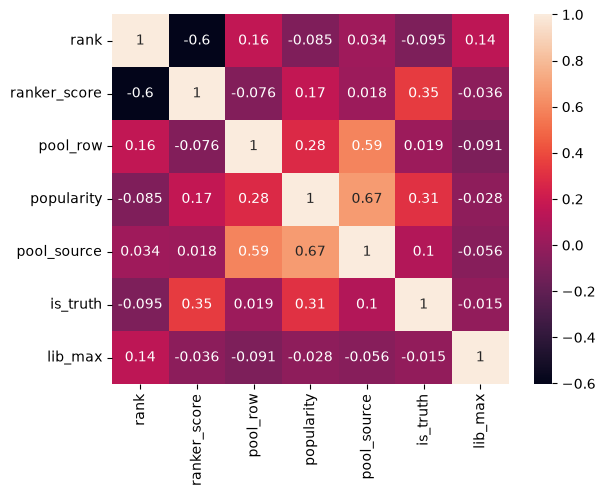

In [57]:
#plot a chat for check input output dependency
corr=df.corr(numeric_only=True)
sns.heatmap(corr,annot=True)

Highly correlated pairs:
rank and ranker_score: -0.603
pool_row and pool_source: 0.588
popularity and pool_source: 0.673


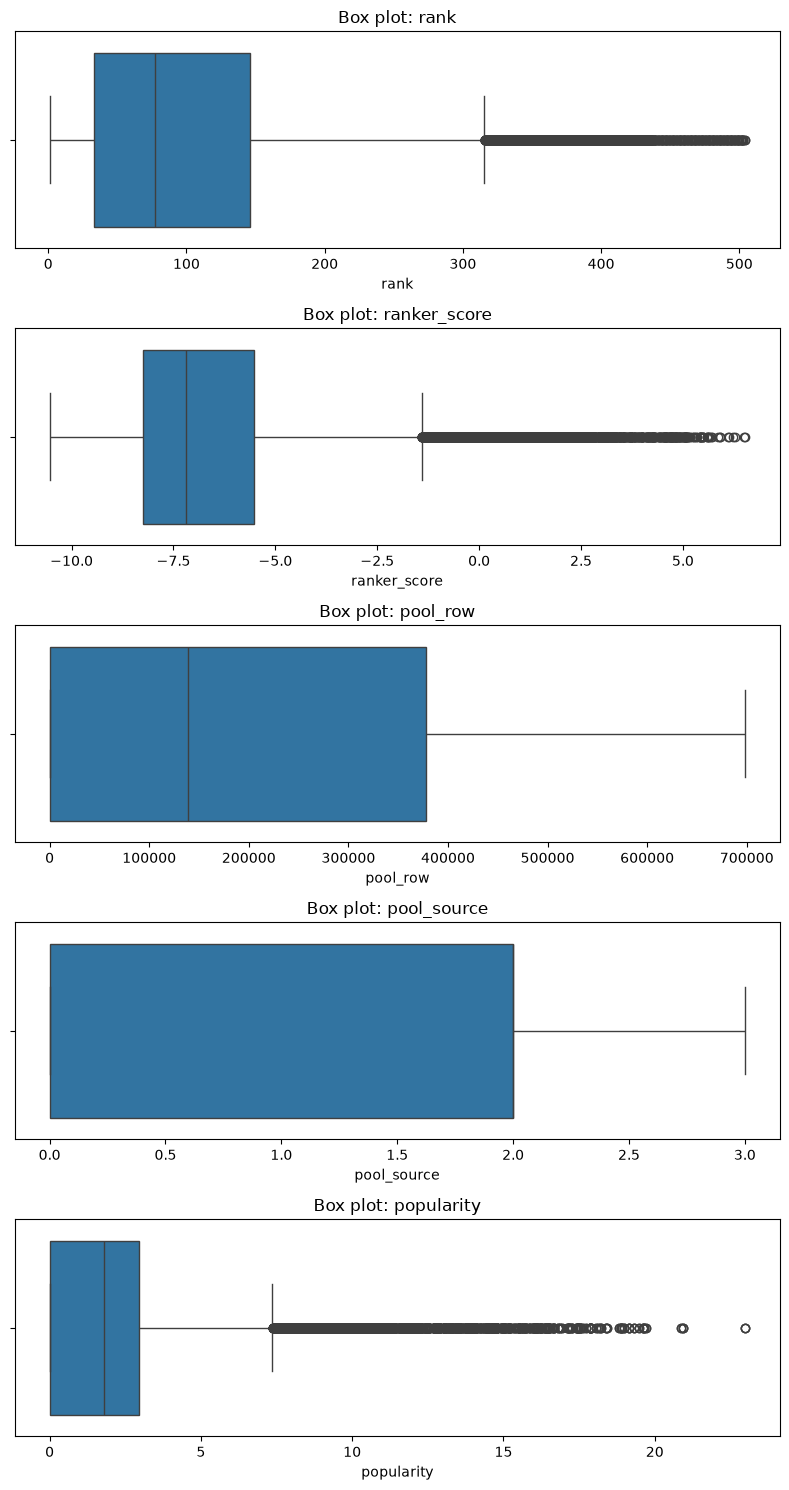

In [58]:
threshold = 0.3
numeric_cols = df.select_dtypes(include="number").columns

high_corr_pairs = [
    (a, b, corr.loc[a, b])
    for i, a in enumerate(corr.columns)
    for b in corr.columns[i + 1:]
    if a in numeric_cols and b in numeric_cols
    and abs(corr.loc[a, b]) >= threshold
]

print("Highly correlated pairs:")
for a, b, value in high_corr_pairs:
    print(f"{a} and {b}: {value:.3f}")

selected_cols = list(dict.fromkeys(
    col for a, b, _ in high_corr_pairs for col in (a, b)
))

if selected_cols:
    fig, axes = plt.subplots(
        len(selected_cols), 1,
        figsize=(8, 3 * len(selected_cols))
    )
    if len(selected_cols) == 1:
        axes = [axes]

    for col, ax in zip(selected_cols, axes):
        sns.boxplot(x=df[col], ax=ax)
        ax.set_title(f"Box plot: {col}")

    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns meet the correlation threshold.")

In [59]:
# Remove outliers using the IQR method on the high-correlation numeric columns
# (keeps only rows that are within the 1.5*IQR range for all selected columns)

selected_cols = ['rank', 'ranker_score', 'pool_row', 'pool_source', 'popularity']

q1 = df[selected_cols].quantile(0.25)
q3 = df[selected_cols].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

mask = ~((df[selected_cols] < lower) | (df[selected_cols] > upper)).any(axis=1)

df = df.loc[mask].copy()

print(f"Original rows: {len(df)} before outlier removal")
print(f"Rows after removing outliers: {len(df)} after removal")

Original rows: 82771 before outlier removal
Rows after removing outliers: 82771 after removal


In [60]:
# Create a cleaned dataset without identifier/text columns
drop_cols = ['scenario', 'molecule', 'candidate_key', 'formula']
df_new = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore').copy()

# Optional: keep only the useful numeric features and target in one dataset
numeric_target_cols = ['rank', 'ranker_score', 'pool_row', 'popularity', 'pool_source', 'lib_max', 'is_truth']
df_model = df_new[numeric_target_cols].copy()

print("Original shape:", df.shape)
print("New dataset shape:", df_new.shape)
print("Model-ready dataset shape:", df_model.shape)
print(df_model.head())

Original shape: (82771, 11)
New dataset shape: (82771, 7)
Model-ready dataset shape: (82771, 7)
   rank  ranker_score  pool_row  popularity  pool_source   lib_max  is_truth
1     2     -1.576765     21555    3.134766            2  0.880166     False
2     3     -3.498401        -1    0.000000            0  0.880166     False
3     4     -4.162638        -1    0.000000            0  0.880166     False
4     5     -4.193504        -1    0.000000            0  0.880166     False
5     6     -4.299180     21554    3.892578            2  0.880166     False


In [61]:
df_model["is_truth"] = df_model["is_truth"].map({True: 1, False: 0})

In [62]:
df_model.head()

,rank,ranker_score,pool_row,popularity,pool_source,lib_max,is_truth
1,2,-1.576765,21555,3.134766,2,0.880166,0
2,3,-3.498401,-1,0.000000,0,0.880166,0
3,4,-4.162638,-1,0.000000,0,0.880166,0
4,5,-4.193504,-1,0.000000,0,0.880166,0
5,6,-4.299180,21554,3.892578,2,0.880166,0


In [63]:
scaler = StandardScaler()
df_model["pool_row"] = scaler.fit_transform(df_model[["pool_row"]])

In [64]:
df_model.head()

,rank,ranker_score,pool_row,popularity,pool_source,lib_max,is_truth
1,2,-1.576765,-0.922649,3.134766,2,0.880166,0
2,3,-3.498401,-1.032489,0.000000,0,0.880166,0
3,4,-4.162638,-1.032489,0.000000,0,0.880166,0
4,5,-4.193504,-1.032489,0.000000,0,0.880166,0
5,6,-4.299180,-0.922654,3.892578,2,0.880166,0


In [65]:
from sklearn.model_selection import train_test_split

X = df_model.drop(columns=["is_truth"])
y = df_model["is_truth"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (66216, 6)
X_test shape: (16555, 6)
y_train shape: (66216,)
y_test shape: (16555,)


In [66]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.cluster import KMeans

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    adjusted_rand_score,
)

models = {
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200, class_weight="balanced", random_state=42, n_jobs=-1
    ),
    "Logistic Regression": make_pipeline(
        StandardScaler(),
        LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42),
    ),
    "Linear SVM": make_pipeline(
        StandardScaler(),
        LinearSVC(class_weight="balanced", random_state=42, max_iter=5000),
    ),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(f"\n{name}")
    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred, zero_division=0))

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        y_score = None

    if y_score is not None and y_test.nunique() == 2:
        print("ROC-AUC:", roc_auc_score(y_test, y_score))

# K-Means: clusters are not supervised class predictions.
kmeans = make_pipeline(
    StandardScaler(),
    KMeans(n_clusters=2, random_state=42, n_init=10),
)
kmeans.fit(X_train)
test_clusters = kmeans.predict(X_test)

print("\nK-Means")
print("Adjusted Rand score:", adjusted_rand_score(y_test, test_clusters))


Decision Tree
Confusion matrix:
 [[16554     0]
 [    1     0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16554
           1       0.00      0.00      0.00         1

    accuracy                           1.00     16555
   macro avg       0.50      0.50      0.50     16555
weighted avg       1.00      1.00      1.00     16555

ROC-AUC: 0.5

Random Forest
Confusion matrix:
 [[16554     0]
 [    1     0]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16554
           1       0.00      0.00      0.00         1

    accuracy                           1.00     16555
   macro avg       0.50      0.50      0.50     16555
weighted avg       1.00      1.00      1.00     16555

ROC-AUC: 0.49858040352784827

Logistic Regression
Confusion matrix:
 [[15979   575]
 [    0     1]]
              precision    recall  f1-score   support

           0       1.00      0.97      0.98     

In [67]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_validate

# Keep candidates from the same scenario/molecule together
groups = (
    df.loc[X_train.index, "scenario"].astype(str)
    + "|"
    + df.loc[X_train.index, "molecule"].astype(str)
)

# Account for class imbalance
class_counts = y_train.value_counts()
scale_pos_weight = class_counts[0] / class_counts[1]

xgb_model = XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(
    xgb_model,
    X_train,
    y_train,
    groups=groups,
    cv=cv,
    scoring={"roc_auc": "roc_auc", "average_precision": "average_precision"},
    n_jobs=1,
)

print(f"Mean ROC-AUC: {scores['test_roc_auc'].mean():.3f} "
      f"+/- {scores['test_roc_auc'].std():.3f}")
print(f"Mean average precision: {scores['test_average_precision'].mean():.3f} "
      f"+/- {scores['test_average_precision'].std():.3f}")

d:\CASMI26 Natural-Product Panel Benchmark\.venv\Lib\site-packages\sklearn\model_selection\_split.py:1036: UserWarning: The least populated class in y has only 3 members, which is less than n_splits=5.
  warnings.warn(
d:\CASMI26 Natural-Product Panel Benchmark\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\CASMI26 Natural-Product Panel Benchmark\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class found in y_true, recall is set to one for all thresholds.
  warnings.warn(
d:\CASMI26 Natural-Product Panel Benchmark\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
d:\CASMI26 Natural-Product Panel Benchmark\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1192: UserWarning: No positive class 

Mean ROC-AUC: nan +/- nan
Mean average precision: 0.001 +/- 0.002


In [68]:
import pickle
from pathlib import Path

# Evaluate all available models on the held-out test set
# and select the best one by ROC-AUC
model_scores = {}

for name, model in models.items():
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)
    else:
        continue

    model_scores[name] = roc_auc_score(y_test, y_score)

# Include XGBoost if it exists
if "xgb_model" in globals():
    xgb_model.fit(X_train, y_train)
    xgb_score = roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1])
    model_scores["XGBoost"] = xgb_score

best_model_name, best_score = max(model_scores.items(), key=lambda item: item[1])
best_model = models.get(best_model_name, xgb_model)

# Save the selected model to a pickle file
save_dir = Path(".")
save_path = save_dir / "best_model.pkl"

with open(save_path, "wb") as f:
    pickle.dump(best_model, f)

print(f"Best model: {best_model_name}")
print(f"ROC-AUC: {best_score:.4f}")
print(f"Saved model to: {save_path.resolve()}")

Best model: Linear SVM
ROC-AUC: 0.9967
Saved model to: D:\CASMI26 Natural-Product Panel Benchmark\best_model.pkl
